# Bài toán hồi quy
Dự đoán tuổi thọ còn lại của ổ đỡ (RUL)
Chương trình tự sinh bộ dữ liệu mô phỏng để chạy ngay trên Colab (Đầu vào là 3 đặc trưng: số giờ vận hành, RMS rung và nhiệt độ ổ đỡ; Đầu ra là RUL); khi làm bài tập hãy thay bằng dữ liệu thật, ví dụ bộ C-MAPSS của NASA.

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Bộ dữ liệu giả lập
rng = np.random.default_rng(42)
n = 600
L     = rng.normal(2000, 260, n).clip(1200, 2800)   # tuoi tho tong
gio   = rng.uniform(0, 1, n) * L                    # so gio da van hanh
mon   = gio / L                                     # muc do mon (an)
rms   = 0.45 + 0.55*mon**1.8 + rng.normal(0, 0.045, n)   # RMS rung
nhiet = 40 + 14*mon + rng.normal(0, 1.6, n)              # nhiet do o do
X = np.c_[gio, rms, nhiet]                          # bang dac trung
y = (L - gio + rng.normal(0, 45, n)).clip(0, None)  # RUL (gio)

# Display the first 10 rows of the generated data
data_df = pd.DataFrame(X, columns=['gio', 'rms', 'nhiet'])
data_df['RUL'] = y
print("Bảng dữ liệu:")
print(data_df.head(10).round(2))
print("...")

Bảng dữ liệu:
       gio   rms  nhiet      RUL
0   855.76  0.55  47.39  1221.44
1  1372.76  0.88  48.46   268.61
2   186.19  0.50  41.17  2040.70
3  1246.76  0.63  48.21   923.09
4  1197.26  0.85  50.75   309.37
5  1536.33  1.01  49.98    85.17
6  1672.51  0.93  51.00   308.54
7    70.90  0.40  39.99  1826.99
8   743.78  0.50  44.98  1243.61
9    86.60  0.52  39.78  1662.62
...


# Hồi qui tuyến tính



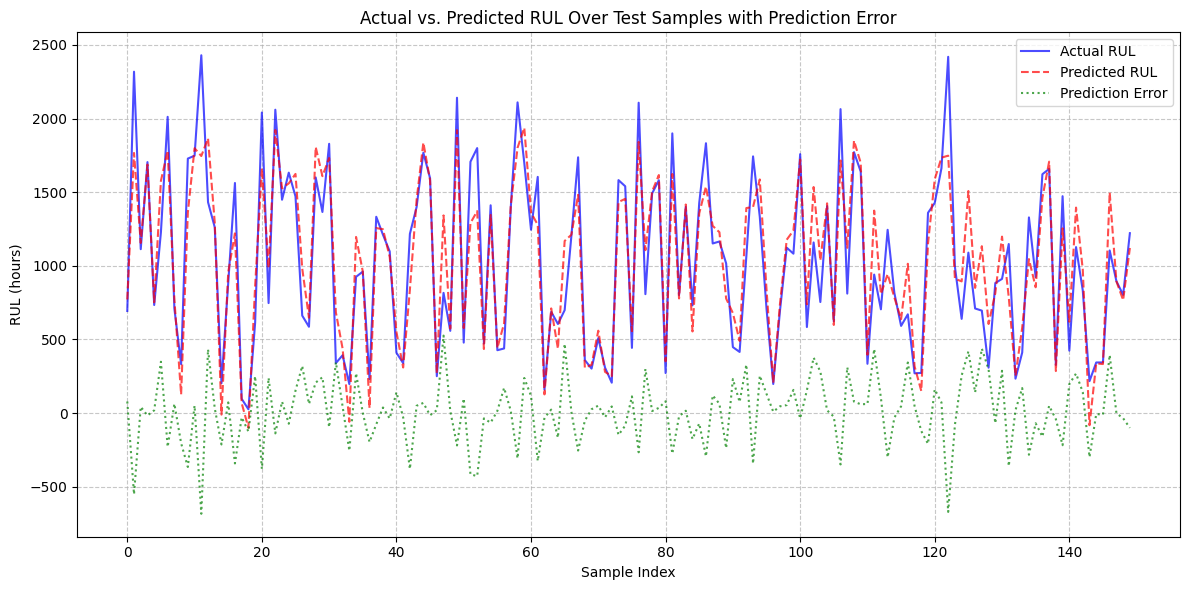

MAE = 168.741 gio
RMSE = 223.651 gio
R2  = 0.851


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error # Import mean_squared_error

# Phân chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Khai báo, huấn luyện mô hình trên dữ liệu "train"
mo_hinh = make_pipeline(StandardScaler(), LinearRegression())
mo_hinh.fit(X_train, y_train)

# Dự đoán trên dữ liệu "test"
y_dd = mo_hinh.predict(X_test)

# Vẽ đồ thị
plt.figure(figsize=(12, 6))
# Plot actual RUL values
sns.lineplot(x=np.arange(len(y_test)), y=y_test, label='Actual RUL', color='blue', alpha=0.7)
# Plot predicted RUL values
sns.lineplot(x=np.arange(len(y_dd)), y=y_dd, label='Predicted RUL', color='red', linestyle='--', alpha=0.7)
# Plot the difference between predicted and actual RUL
sns.lineplot(x=np.arange(len(y_test)), y=y_dd - y_test, label='Prediction Error', color='green', linestyle=':', alpha=0.7)

plt.xlabel('Sample Index')
plt.ylabel('RUL (hours)')
plt.title('Actual vs. Predicted RUL Over Test Samples with Prediction Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Đánh giá mô hình
print("MAE = %.3f gio" % mean_absolute_error(y_test, y_dd))
print("RMSE = %.3f gio" % np.sqrt(mean_squared_error(y_test, y_dd))) # Calculate and print RMSE
print("R2  = %.3f" % r2_score(y_test, y_dd))

# Ridge

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error # Import mean_squared_error

mo_hinh = make_pipeline(StandardScaler(), Ridge(alpha=1))
mo_hinh.fit(X_train, y_train)
y_dd = mo_hinh.predict(X_test)

print("MAE = %.3f gio" % mean_absolute_error(y_test, y_dd))
print("RMSE = %.3f gio" % np.sqrt(mean_squared_error(y_test, y_dd))) # Calculate and print RMSE
print("R2  = %.3f" % r2_score(y_test, y_dd))

MAE = 168.707 gio
RMSE = 223.627 gio
R2  = 0.851


# Lasso

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error # Import mean_squared_error

mo_hinh = make_pipeline(StandardScaler(), Lasso(alpha=0.1))
mo_hinh.fit(X_train, y_train)
y_dd = mo_hinh.predict(X_test)

print("MAE = %.3f gio" % mean_absolute_error(y_test, y_dd))
print("RMSE = %.3f gio" % np.sqrt(mean_squared_error(y_test, y_dd))) # Calculate and print RMSE
print("R2  = %.3f" % r2_score(y_test, y_dd))

MAE = 168.736 gio
RMSE = 223.653 gio
R2  = 0.851


# So sánh hồi quy tuyến tính, Ridge và Lasso

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

for ten, mo in [("Tuyen tinh", LinearRegression()),
                ("Ridge", Ridge(alpha=1.0)),
                ("Lasso", Lasso(alpha=0.1))]:
    pipe = make_pipeline(StandardScaler(), mo).fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print("%-10s MAE = %6.1f | RMSE = %6.1f | R2 = %.3f | he so = %s"
          % (ten,
             mean_absolute_error(y_test, y_pred),
             np.sqrt(mean_squared_error(y_test, y_pred)),
             r2_score(y_test, y_pred),
             np.round(pipe[-1].coef_, 1)))

Tuyen tinh MAE =  168.7 | RMSE =  223.7 | R2 = 0.851 | he so = [-134.8 -230.6 -231.8]
Ridge      MAE =  168.7 | RMSE =  223.6 | R2 = 0.851 | he so = [-136.7 -229.4 -230.6]
Lasso      MAE =  168.7 | RMSE =  223.7 | R2 = 0.851 | he so = [-134.7 -230.6 -231.8]
